In [1]:
using DifferentialEquations, LinearAlgebra, Plots
Threads.nthreads()

20

### Initialization

In [2]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ψ_0 = [ψ_a,g,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)')

8×8 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

### Functions

In [3]:
struct parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
 end

In [4]:
nothing
function (p::parameters)(t)
    global Δ1_0 = Δ1_0
    global δ1 =  δ1
    global Δ2_0 = Δ2_0
    global δ2 =  δ2

    tf = 412
    if t<tf
        return (Δ1_0-δ1*t, Δ2_0, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    else
        return (Δ1_0-δ1*t, Δ2_0-δ2*(t-tf), p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    end
end


#Master Equation
nothing
function master_eqn(dρ,ρ,p,t)

    n_atoms = 2
    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ1_t, Δ2_t, Ω1, Ω2, γ_Decay, γ_dephase, V1_nn, V2_nn = p(t)


    #Hamiltonian elements
    nn_sys = [kron(n,n,I), kron(I,n,n)] 
    σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

    #Hamiltonian
    H = Ω1/2 .* σx_sys[1] + Ω2/2 .* σx_sys[2] + V1_nn .* nn_sys[1] + V2_nn.* nn_sys[2] +
        Δ1_t .* n_sys[1] + Δ2_t .*n_sys[2]

    #lindbaldian terms
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))

    for i in 1:2
        l_decay += γ_Decay.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_dephase.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end


#Solving the master equation
nothing
function solve_master_eqn(p)
    global δ1 = δ1
    tspan = (0.0,2*(Δ1_0+p(0)[end-1])/δ1)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    sol = solve(eqn, Rodas3(autodiff=false),saveat=1)
    return sol
end


# Extracting populations from the solution
nothing
function rydberg_populations(sol)
    n = [0 0; 0 1]
    I = [1 0; 0 1]

    a = reduce(kron,[I,n,I])
    rydberg1 = [real(tr(a*ρ)) for ρ in sol.u]

    b = reduce(kron,[I,I,n])
    rydberg2 = [real(tr(b*ρ)) for ρ in sol.u]

    c = reduce(kron,[I,n,n])
    rydberg12 = [real(tr(c*ρ)) for ρ in sol.u]

    return rydberg1, rydberg2, rydberg12
end

rydberg_populations (generic function with 1 method)

### System Dynamics

In [23]:
Δ1_0 = 1031.60696125856
δ1 = 0.108573620475813
Δ2_0 = 1031.60696125856
δ2 = 0.108573620475813
p = parameters(1,1,0.001,0,-1000,-1000)

tspan = (0.0,2*582)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
solution = solve(eqn, Rodas3(autodiff=false),saveat=1);

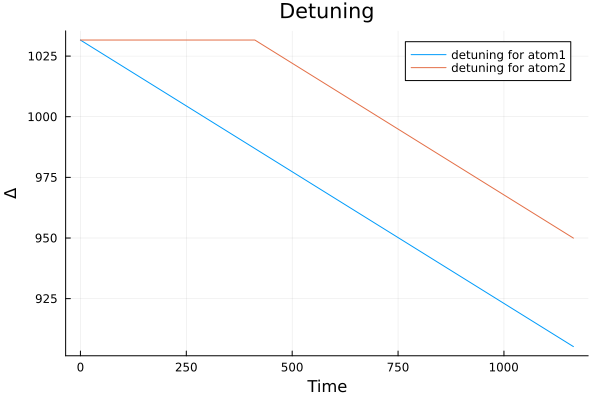

In [24]:
T = solution.t
Δ1_T = Array{Float64}(undef,length(T))
Δ2_T = Array{Float64}(undef,length(T))

for i in 1:length(T)
    t = T[i]
    Δ1_T[i] = p(t)[1]
    Δ2_T[i] = p(t)[2]
end
plot(T,Δ1_T,label="detuning for atom1",xaxis="Time",yaxis="Δ",title="Detuning")
plot!(T,Δ2_T,label="detuning for atom2",xaxis="Time",yaxis="Δ",title="Detuning")

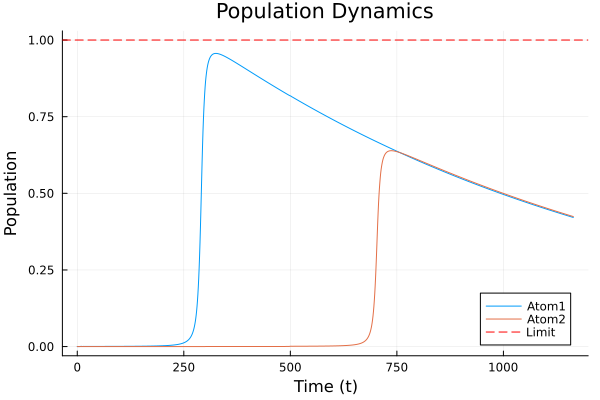

In [25]:
r1,r2,r12 = rydberg_populations(solution)

# Plotting the Rydberg state population over time
plot(solution.t, r1, label="Atom1", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
plot!(solution.t, r2, label="Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
hline!([1],color=:red,linestyle=:dash,label="Limit")

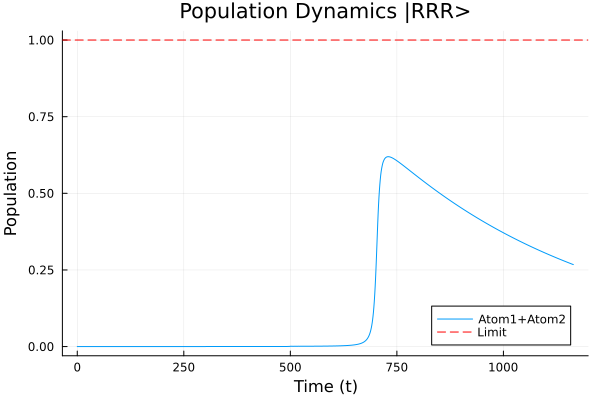

In [26]:
plot(solution.t, r12, label="Atom1+Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics |RRR>")
hline!([1],color=:red,linestyle=:dash,label="Limit")

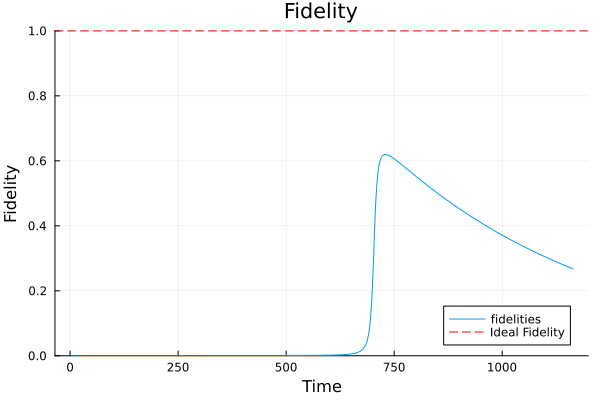

In [27]:
a = [r,r,r]
b = [g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)

fidelities = []
time = []
for (t,ρ) in zip(solution.t,solution.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

### Observations

In [28]:
r1_end = r1[412]
r2_end = r2[end]
println("The population of the Rydberg state for atom1 is $r1_end which is equivalent to P_LZ = 1e-4 + some numerical inconsistencies
The population of Rydberg state for atom2 is $r2_end which is equivalent to P_LZ = 1e-4 but also depends on previous atom population")

The population of the Rydberg state for atom1 is 0.8924620056468827 which is equivalent to P_LZ = 1e-4 + some numerical inconsistencies
The population of Rydberg state for atom2 is 0.42418493922424155 which is equivalent to P_LZ = 1e-4 but also depends on previous atom population
